# **Hate Speech and Offensive Content Detection**

## **1. Business Understanding**
### *Overview*
In Kenya's digital landscape, Twitter plays a critical role in shaping public discourse, especially during election seasons and politically charged events. While it provides a platform for civic engagement, it also facilitates the spread of hate speech, tribalism, and inciting language. This content can escalate tensions and contribute to real-world conflict if left unchecked.
### *Challenges*
Manually moderating large volumes of tweets is inefficient and prone to bias. Current moderation systems struggle to scale and often miss localized forms of hate speech, particularly those specific to Kenyan cultural and political contexts. There is also a lack of automated tools specifically designed to detect offensive content within Kenyan tweets.
### *Proposed Solution*
Develop a machine learning model that can automatically categorize tweets into three classes: hate speech, offensive content, or neither. The model will serve as a content flagging tool for:
Early detection of harmful tweets during elections or national events.
Support for content moderation teams at media outlets, regulatory bodies, and social platforms.
Enhancing digital safety by tracking the evolution and spread of dangerous speech trends.


An effective classification model tailored to the Kenyan context can reduce the spread of inciting content and improve the quality of online public discourse. This system would be vital in promoting peace, especially during sensitive periods like elections.

### *Problem Statement*
There is an urgent need for a localized and scalable hate speech detection system to flag inciting and offensive tweets in Kenya, particularly during political periods where online speech can incite real-world unrest.

### *Objectives*
- To evaluate the most common terms or phrases used in inciting tweets.
- To build a multi-class classification model that labels tweets as hate speech, offensive, or neither.
- To evaluate model performance across different algorithms using accuracy.
- To Deploy the best performing model using Streamlit

## **2 Data Understanding**
The dataset used in this project, HateSpeech_Kenya.csv, was sourced from Kaggle, a well-known platform for sharing datasets and machine learning challenges. It contains approximately 48,000 tweets labeled for sentiment and hate speech, specifically focused on the Kenyan social and political context.
Key Features of the Data:
`tweet`: The raw text of the tweet . this forms the primary input for natural language processing and classification tasks.
`label`: The target variable, where 0 represents neutral content and 1 represents offensive content and 2 represent hate speech.

This dataset is directly aligned with the project goal of developing a machine learning model to detect and categorize hate speech in Kenyan tweets. The inclusion of localized language, real-world offensive content, and metadata allows the model to learn patterns specific to the Kenyan context.


### *Importing Dependencies*

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Text Preprocessing
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Utilities
import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk import word_tokenize
from nltk import FreqDist
nltk.download('wordnet')
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Filter Warnings
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


c:\Users\chris\anaconda3\anaconda4\envs\learn-env\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chris\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
c:\Users\chris\anaconda3\anaconda4\envs\learn-env\lib\site-packages\xgboost\compat.py:93: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


## **3 Data Preparation**


In [2]:
# Loading the dataset, Mapping Class with respective Labels
df = pd.read_csv('HateSpeech_Kenya.csv')
df['Tweet'] = df['Tweet'].apply(lambda x: ' '.join(eval(x)) if isinstance(x, str) else x)
label_map = {0: 'Neutral', 1: 'Offensive', 2: 'Hate Speech'}
df['Label'] = df['Class'].map(label_map)
df.tail()


,hate_speech,offensive_language,neither,Class,Tweet,Label
48071,0,0,2,0,This is exactly what Moses Kuria & ilk are doi...,Neutral
48072,0,0,2,0,This is exactly what Kenyans are going through...,Neutral
48073,0,0,2,0,This is exactly what is wrong with this countr...,Neutral
48074,1,0,2,0,This is exactly the same thing. Well the only ...,Neutral
48075,0,1,2,0,This is exactly how Luos feel in this country ...,Neutral


### *Extracting the Relevant Columns*

In [3]:
new_df = df[['Tweet', 'Class', 'Label']]
new_df.head()

,Tweet,Class,Label
0,The political elite are in desperation. Ordina...,0,Neutral
1,Am just curious the only people who are callin...,0,Neutral
2,USERNAME_3 the area politicians are the one to...,0,Neutral
3,War expected in Nakuru if something is not don...,0,Neutral
4,USERNAME_4 tells kikuyus activists that they a...,0,Neutral


### *Dataset Summary*

In [4]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48076 entries, 0 to 48075
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweet   48076 non-null  object
 1   Class   48076 non-null  int64 
 2   Label   48076 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


### *Checking for Duplicates*

In [5]:
new_df.duplicated().sum()  # Check for duplicates (entire DataFrame)

0

In [6]:
new_df.drop_duplicates(inplace=True)  # Drop duplicates

### *Feature Engineering*

In [7]:
# creating columns for number of characters, number of sentences and number of words
new_df["char"]=new_df["Tweet"].apply(lambda x:len(x))
new_df["words"]=new_df["Tweet"].apply(lambda x:nltk.word_tokenize(x)).apply(lambda x:len(x))
new_df["sentences"]=new_df["Tweet"].apply(lambda x:nltk.sent_tokenize(x)).apply(lambda x:len(x))
new_df.sample(10)

,Tweet,Class,Label,char,words,sentences
12118,Yeahhhh.. USERNAME_2197 and I are very happy w...,0,Neutral,138,21,1
14495,While Jomo Kenyatta was working for colonialis...,0,Neutral,139,22,2
12443,Worrying me is the twists and turns of the #Ju...,0,Neutral,138,28,3
18712,To them burning tires gas bombs hurled rocks a...,0,Neutral,201,36,2
37729,Luhyas are peacefull people those fighting at ...,0,Neutral,67,11,1
8940,Be like bruh! We got some net-worth to chase !...,0,Neutral,115,25,5
46346,Understanding Elections and Civic Responsibility,0,Neutral,48,5,1
16232,What business do you have there if you r no la...,0,Neutral,127,26,2
32571,To kikuyus Joho's achievments in life are absu...,1,Offensive,139,29,2
1472,Where are Luhyas for USERNAME_254 .Please RT. ...,0,Neutral,51,10,2


### *Summary Statistics*

In [8]:
new_df.describe()

,Class,char,words,sentences
count,48076.000000,48076.000000,48076.000000,48076.000000
mean,0.310030,110.663637,20.334054,1.798174
std,0.588431,48.989947,9.505972,0.991620
min,0.000000,1.000000,1.000000,1.000000
25%,0.000000,79.000000,14.000000,1.000000
50%,0.000000,111.000000,20.000000,2.000000
75%,0.000000,135.000000,25.000000,2.000000
max,2.000000,327.000000,68.000000,14.000000


### *Check Target Values*

In [9]:
features = ['Class', 'Label']
for feature in features:
    print(f"Unique values in {feature}: {new_df[feature].unique()}")

Unique values in Class: [0 1 2]
Unique values in Label: ['Neutral' 'Offensive' 'Hate Speech']


### *Text Cleaning*

Raw tweets often contain noise such as:
- URLs
- Mentions
- Hashtags
- Emojis and non-alphanumeric characters

We'll apply basic text preprocessing to clean the tweet data.


In [10]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    item = re.sub(r'\@\w+|\#', '', text)  # Remove mentions and hashtags 
    item = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove non-alphabetic
    text = text.lower().strip()             # convert to lowercase and strip whitespace
    return text

new_df['Clean_Tweet'] = new_df['Tweet'].apply(clean_text)
new_df.head()

,Tweet,Class,Label,char,words,sentences,Clean_Tweet
0,The political elite are in desperation. Ordina...,0,Neutral,93,14,2,the political elite are in desperation ordinar...
1,Am just curious the only people who are callin...,0,Neutral,138,26,1,am just curious the only people who are callin...
2,USERNAME_3 the area politicians are the one to...,0,Neutral,132,22,1,username the area politicians are the one to b...
3,War expected in Nakuru if something is not don...,0,Neutral,112,23,3,war expected in nakuru if something is not don...
4,USERNAME_4 tells kikuyus activists that they a...,0,Neutral,120,21,3,username tells kikuyus activists that they are...


### EDA

We'll visualize class distribution, tweet lengths, and word frequencies to better understand the dataset.

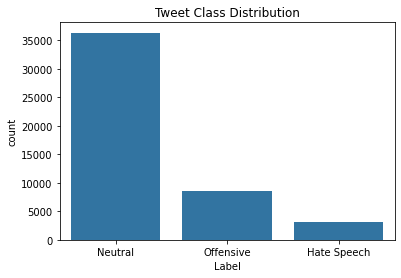

In [11]:
# Class distribution
sns.countplot(data=new_df, x='Label')
plt.title('Tweet Class Distribution')
plt.show()


### Box plot of the distribution of number of characters accross classes/label

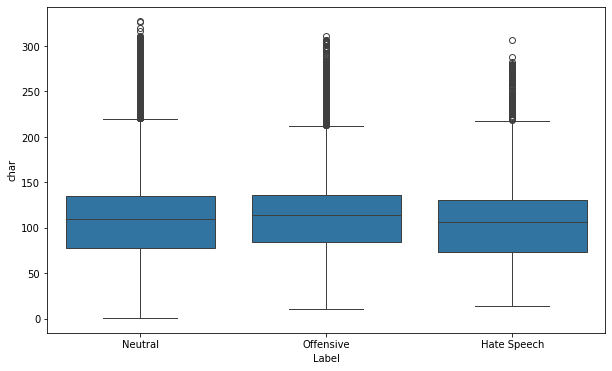

In [12]:

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=new_df,
    x='Label',               
    y='char') 
            
plt.title='Character Count Distribution by Label'
plt.xlabel='Label',
plt.ylabel='Number of Characters'
plt.show()



### Box plot of the distribution of number of words accross classes/label

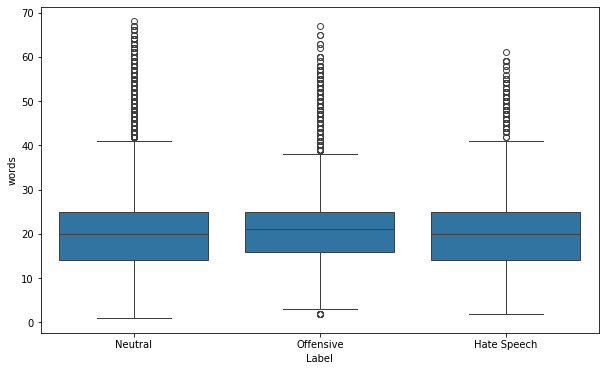

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=new_df,
    x='Label',               
    y='words') 
            
plt.title='Character Count Distribution by Label'
plt.xlabel='Label',
plt.ylabel='Number of Words'
plt.show()

### Box plot of the distribution of number of sentences accross classes/label

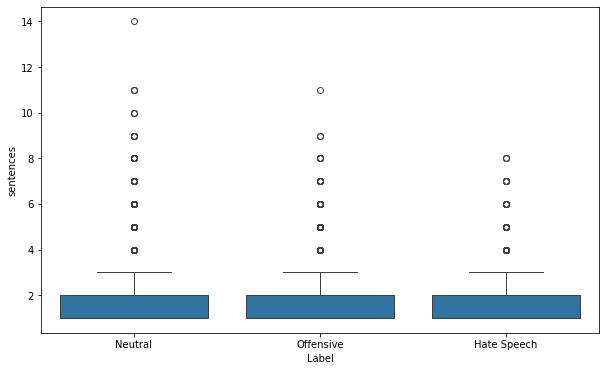

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=new_df,
    x='Label',               
    y='sentences') 
            
plt.title='Character Count Distribution by Label'
plt.xlabel='Label',
plt.ylabel='Number of Sentences'
plt.show()

### Text preprocessing
Tokenizzing , selecting words with 3 or more characters, removing stop words

In [15]:
# Tokenizer that uses a regex pattern to select words with three or more characters
tokenizer = RegexpTokenizer(r"(?u)\w{3,}")

# List of stopwords in English
english_stopwords = stopwords.words('english')
swahili_stopwords = [
    "a", "na", "ya", "kwa", "wa", "ni", "la", "ili", "katika", "juu", "chini", "kama", "pia", "hadi", "toka",
    "lakini", "kwamba", "hata", "bado", "baada", "mbele", "nyuma", "tu", "tena", "sana", "zote", "wote", "sisi",
    "wao", "wewe", "mimi", "yeye", "huu", "hii", "hawa", "hao", "hizo", "wale", "wetu", "wako", "wangu", "hivyo",
    "au", "kuwa", "ame", "alikuwa", "walikuwa", "si", "ha", "ambapo", "kwani", "ndio", "bila", "kila", "baadhi",
    "mara", "zaidi", "kati", "kupitia"]

sheng_stopwords = [
    "ati", "ajee", "aje", "manze", "yani", "venye", "vile", "niko", "uko", "ako", "nko", "si", "ni", "kaa",
    "hivo", "ivo", "ngori", "ebu", "ah", "lo", "aa", "maze", "fiti", "dem", "boyie", "wasee", "mabeshte", "buda",
    "brathe", "msee", "mresh", "jamaa", "bro", "sis", "sanaa", "kweli", "freshi", "mbogi", "hadi", "balaa",
    "noma", "walai", "ju", "ama", "bado", "mbaya", "vile", "nani", "kitu", "place", "hio", "hiyo", "hii", "ile",
    "nyinyi", "sisi", "mimi", "wewe", "wao", "yeye"
]

# Combine all stopwords list
stopwords_list = set(english_stopwords + swahili_stopwords + sheng_stopwords)

# Use Lemmatizer
lemmatizer = WordNetLemmatizer()

In [16]:
def preprocess_text(text, tokenizer, stopwords_list, lemmatizer):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    words = [word for word in tokens if word not in stopwords_list]
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return lemmatized_words

### Performing preprocessing on the clean tweet feature


In [17]:
text_data = new_df['Clean_Tweet'].apply(lambda x: preprocess_text(x, tokenizer, stopwords_list, lemmatizer))
text_data.tail()

48071    [exactly, moses, kuria, ilk, say, negative, et...
48072    [exactly, kenyan, going, thank, god, time, ric...
48073    [exactly, wrong, country, kikuyus, cant, stand...
48074    [exactly, thing, well, difference, kilifi, the...
48075    [exactly, luo, feel, country, like, moses, kur...
Name: Clean_Tweet, dtype: object

### Adding preprocessed tweet as a column

In [18]:
new_df["Preprocessed_Tweet"] = text_data
new_df.head()

,Tweet,Class,Label,char,words,sentences,Clean_Tweet,Preprocessed_Tweet
0,The political elite are in desperation. Ordina...,0,Neutral,93,14,2,the political elite are in desperation ordinar...,"[political, elite, desperation, ordinary, kale..."
1,Am just curious the only people who are callin...,0,Neutral,138,26,1,am just curious the only people who are callin...,"[curious, people, calling, old, mad, kikuyus, ..."
2,USERNAME_3 the area politicians are the one to...,0,Neutral,132,22,1,username the area politicians are the one to b...,"[username, area, politician, one, blame, coz, ..."
3,War expected in Nakuru if something is not don...,0,Neutral,112,23,3,war expected in nakuru if something is not don...,"[war, expected, nakuru, something, done, luo, ..."
4,USERNAME_4 tells kikuyus activists that they a...,0,Neutral,120,21,3,username tells kikuyus activists that they are...,"[username, tell, kikuyus, activist, targeted, ..."


### Frequency Dist Of Preprocessed Words

In [19]:
frequency_dist = FreqDist(new_df['Preprocessed_Tweet'].explode())
frequency_dist

FreqDist({'username': 15522, 'kikuyus': 7361, 'luo': 5223, 'noreformsnoelections': 4032, 'nyakundi': 2933, 'kenya': 2855, 'people': 2672, 'kenyan': 2529, 'like': 2357, 'one': 2125, ...})

### Distribution of top 20 words 

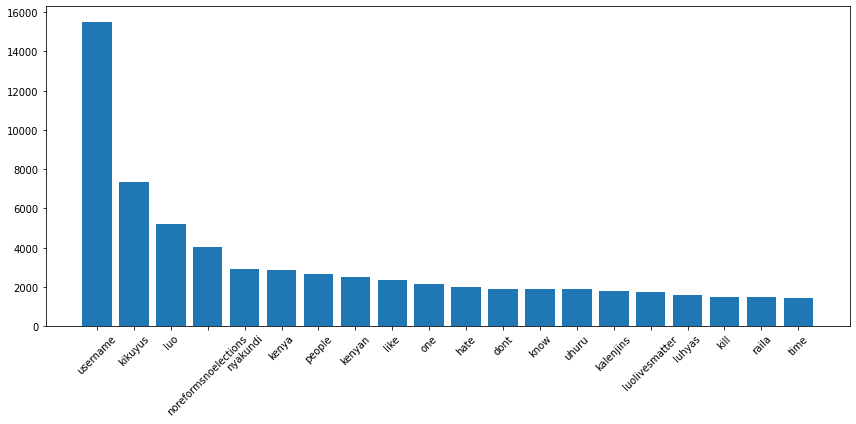

In [20]:

# Sort the dictionary by value (descending)
sorted_dict = dict(sorted(frequency_dist.items(), key=lambda x: x[1], reverse=True))

# Take the top 20 Words
top_20 = dict(list(sorted_dict.items())[:20])

keys = [str(k) for k in top_20.keys()]
values =  list( top_20.values())

plt.figure(figsize=(12, 6))
plt.bar(top_20.keys(), top_20.values())
plt.title=("Distribution of top 20 Words in Tweets")
plt.xlabel=("Words")
plt.ylabel=("Count")
plt.xticks(rotation=45)  

plt.tight_layout()  
plt.show()

## Word Cloud PLot
# from wordcloud import WordCloud

### Getting rid of the word "username"

In [21]:
new_df["Clean_Tweet"] = new_df["Clean_Tweet"].str.replace("username", "", regex=False).str.strip()
  

In [22]:
text_data = new_df['Clean_Tweet'].apply(lambda x: preprocess_text(x, tokenizer, stopwords_list, lemmatizer))
new_df["Preprocessed_Tweet"] = text_data
new_df.head()

,Tweet,Class,Label,char,words,sentences,Clean_Tweet,Preprocessed_Tweet
0,The political elite are in desperation. Ordina...,0,Neutral,93,14,2,the political elite are in desperation ordinar...,"[political, elite, desperation, ordinary, kale..."
1,Am just curious the only people who are callin...,0,Neutral,138,26,1,am just curious the only people who are callin...,"[curious, people, calling, old, mad, kikuyus, ..."
2,USERNAME_3 the area politicians are the one to...,0,Neutral,132,22,1,the area politicians are the one to blame coz ...,"[area, politician, one, blame, coz, insiting, ..."
3,War expected in Nakuru if something is not don...,0,Neutral,112,23,3,war expected in nakuru if something is not don...,"[war, expected, nakuru, something, done, luo, ..."
4,USERNAME_4 tells kikuyus activists that they a...,0,Neutral,120,21,3,tells kikuyus activists that they are being ta...,"[tell, kikuyus, activist, targeted, targetted,..."


### Distribution of Words by LABEL/CLASS

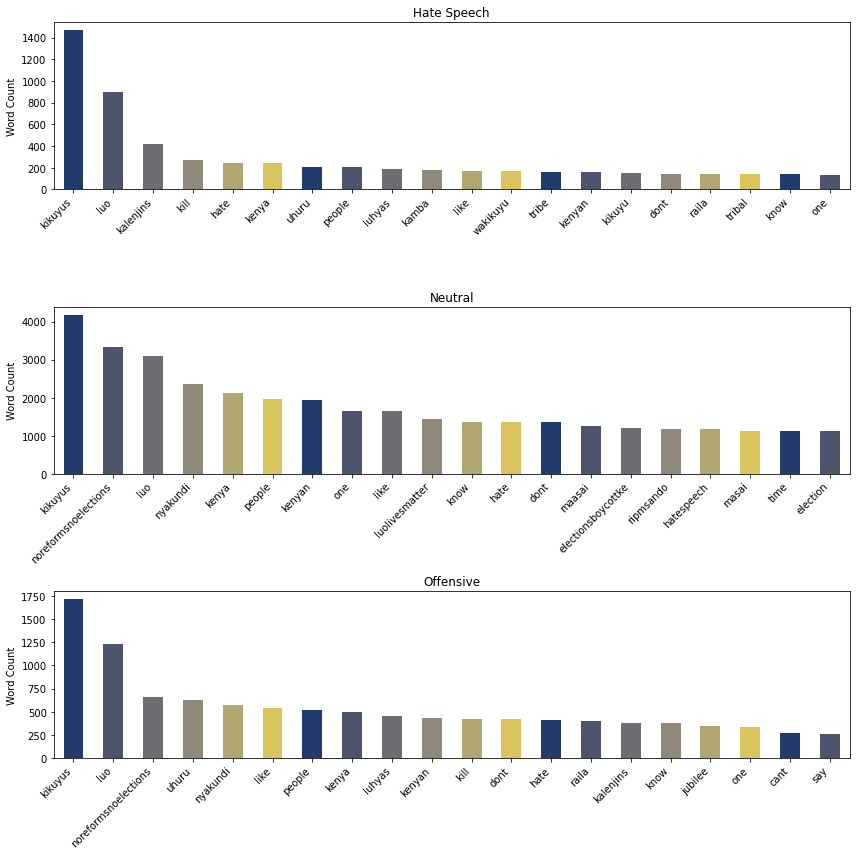

In [23]:
fig, axes = plt.subplots(nrows=3, figsize=(12, 12))
color_palette = sns.color_palette('cividis')  # Unlimited colors from palette

for idx, label_df in enumerate(new_df.groupby('Label')):
    label_name, group_data = label_df
    all_words = group_data['Preprocessed_Tweet'].explode()
    top_20 = all_words.value_counts().nlargest(20)
    
    # Plot with automatic color cycling
    ax = axes[idx]
    top_20.plot.bar(ax=ax, color=color_palette)
    ax.set_title(label_name.title())
    ax.set_xticklabels(top_20.index, rotation=45, ha='right')
    ax.set_ylabel('Word Count')

fig.tight_layout()
plt.show()

### Word Cloud

In [24]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


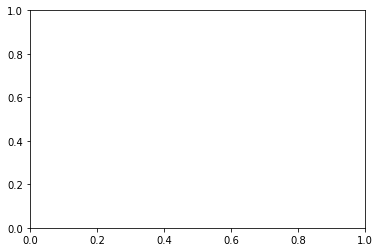

In [25]:
import matplotlib.pyplot as plt
plt.title = plt.gca().set_title  # Restore the correct title function

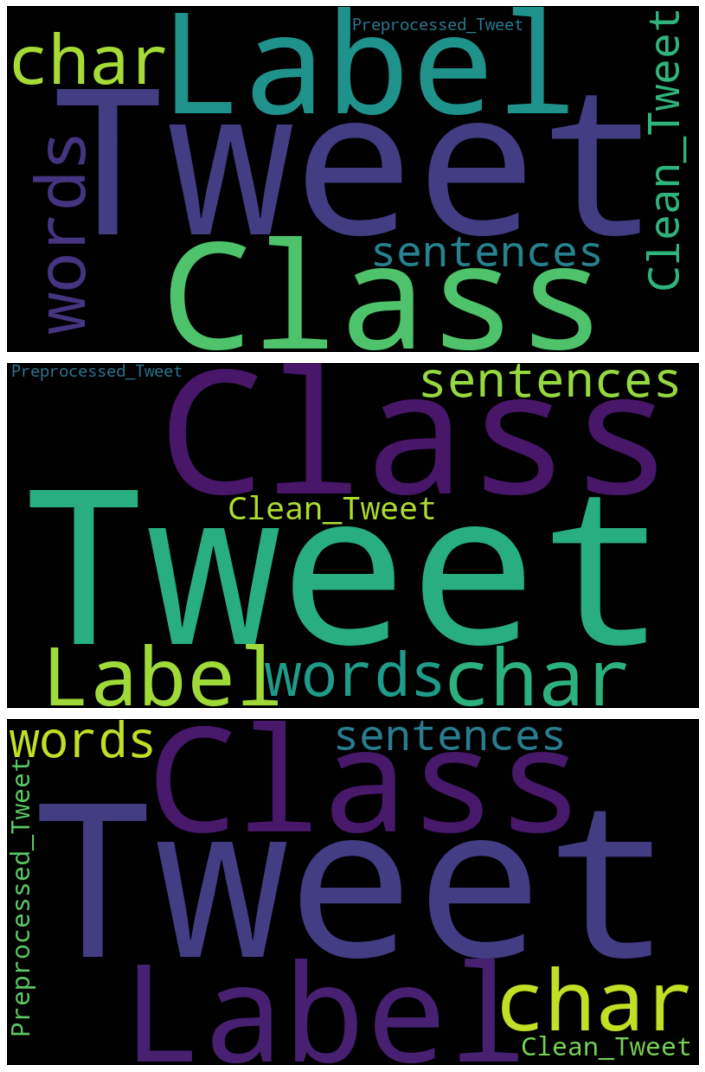

In [26]:
from wordcloud import WordCloud

# List of sentiment classes (ensure they match the values in your DataFrame exactly)
sentiments = ['Neutral', 'Offensive', 'Hate Speech']

# Set figure size for vertical layout
plt.figure(figsize=(10, 15))

# Generate and plot word cloud for each sentiment
for i, sentiment in enumerate(sentiments, 1):
    text = " ".join(
        new_df[new_df['Label'].str.lower() == sentiment].astype(str)
    )

    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='black',
        colormap='viridis',
        max_words=200
    ).generate(text)

    # Plot in a separate row
    plt.subplot(3, 1, i)  
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"{sentiment.capitalize()} Tweets", fontsize=16)
    plt.axis('off')

plt.tight_layout()
plt.show()

## **4. Modelling**

In [27]:
#defining x and y
X=new_df["Preprocessed_Tweet"]
y=new_df["Class"]

In [28]:
#train test split 
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

In [29]:
X_train = X_train.apply(lambda x: " ".join(x) if isinstance(x, list) else x)
X_test = X_test.apply(lambda x: " ".join(x) if isinstance(x, list) else x)


### *Baseline Model*

In [30]:
from sklearn.pipeline import Pipeline
pipe=Pipeline([("vect",TfidfVectorizer()),
               ("clf",LogisticRegression())])
pipe.fit(X_train,y_train)
pred=pipe.predict(X_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.78      0.97      0.86      7271
           1       0.42      0.11      0.18      1709
           2       0.40      0.11      0.17       636

    accuracy                           0.76      9616
   macro avg       0.53      0.40      0.41      9616
weighted avg       0.69      0.76      0.70      9616



In [31]:
# defining the word embeddings
X_train_bert = np.load("X_train_bert.npy", allow_pickle=True)
X_test_bert = np.load("X_test_bert.npy", allow_pickle=True)

In [32]:
# trying out the baseline model with git embeddings
from sklearn.linear_model import LogisticRegression

clf =LogisticRegression()
clf.fit(X_train_bert, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test_bert)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.96      0.86      7271
           1       0.42      0.11      0.18      1709
           2       0.36      0.13      0.19       636

    accuracy                           0.76      9616
   macro avg       0.52      0.40      0.41      9616
weighted avg       0.69      0.76      0.70      9616



### *Cross Validation*

In [33]:
# cross validating candidate models with the word embeddings
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'GaussianNB': GaussianNB(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Store results
results = []

for name, model in models.items():
    print(f"Training {name}...")

    # GaussianNB requires dense input
    if name == 'GaussianNB':
        model.fit(X_train_bert, y_train)
        y_pred = model.predict(X_test_bert)
        y_prob = model.predict_proba(X_test_bert)
    else:
        model.fit(X_train_bert, y_train)
        y_pred = model.predict(X_test_bert)
        y_prob = model.predict_proba(X_test_bert)
    
    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    try:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    except:
        auc = None  # In case probability output is missing

    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1 Score': report['macro avg']['f1-score'],
        'ROC AUC': auc
    })

# Display results
pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)


Training Logistic Regression...
Training GaussianNB...
Training Random Forest...
Training XGBoost...
[13:06:35] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { use_label_encoder } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.756760,0.528523,0.411933,0.423018,0.758075
1,GaussianNB,0.573523,0.413285,0.485468,0.405111,0.676888
3,XGBoost,0.755928,0.525658,0.380255,0.380289,0.748893
2,Random Forest,0.756760,0.561296,0.342841,0.307813,0.682331


## Comparison of the top 2 models with SMOTE
After comparison the top 2 models we obtained were the Logistic Regression Model and the Random Forest model due to their strong metrics especially the F1-score for theminority class in the RandomForest model
Since class imbalance is a major hinderance within our model we decided to apply SMOTE to deal with it to see whether it will improve our metrics and which will perform the best of the two

In [34]:
# Loading BERT embeddings
X_train = np.load('X_train_bert.npy')
X_test = np.load('X_test_bert.npy')



### Defining evaluation functions

We define evaluation functions  to ensure a consistent, reusable, and efficient process for training and evaluating different machine learning models. 
This function simplifies the workflow by including optional SMOTE application for handling class imbalance, standardizes performance reporting using key metrics like the weighted F1-score

In [35]:
def evaluate_model(model, X_train, y_train, X_test, y_test, use_smote=False):
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print(f"SMOTE Applied: Original={len(y_train)}, Resampled={len(y_train_res)}")
    else:
        X_train_res, y_train_res = X_train, y_train
    
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"{'With' if use_smote else 'Without'} SMOTE - F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    
    return f1


#### Model comparisons

In [36]:
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

print("\n----- Logistic Regression -----")
f1_lr_no_smote = evaluate_model(lr, X_train, y_train, X_test, y_test, use_smote=False)
f1_lr_smote = evaluate_model(lr, X_train, y_train, X_test, y_test, use_smote=True)

print("\n----- Random Forest -----")
f1_rf_no_smote = evaluate_model(rf, X_train, y_train, X_test, y_test, use_smote=False)
f1_rf_smote = evaluate_model(rf, X_train, y_train, X_test, y_test, use_smote=True)



----- Logistic Regression -----
Without SMOTE - F1 Score: 0.6280
              precision    recall  f1-score   support

           0       0.89      0.61      0.72      7271
           1       0.28      0.44      0.34      1709
           2       0.21      0.62      0.31       636

    accuracy                           0.58      9616
   macro avg       0.46      0.56      0.46      9616
weighted avg       0.73      0.58      0.63      9616

SMOTE Applied: Original=38460, Resampled=87243
With SMOTE - F1 Score: 0.6337
              precision    recall  f1-score   support

           0       0.88      0.63      0.73      7271
           1       0.27      0.43      0.34      1709
           2       0.21      0.58      0.31       636

    accuracy                           0.59      9616
   macro avg       0.45      0.55      0.46      9616
weighted avg       0.73      0.59      0.63      9616


----- Random Forest -----
Without SMOTE - F1 Score: 0.6577
              precision    recall  

### Hybrid method

In [ ]:

from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Hybrid method for better class separation
def evaluate_hybrid_model(model, X_train, y_train, X_test, y_test):
    smt = SMOTETomek(random_state=42)
    X_train_res, y_train_res = smt.fit_resample(X_train, y_train)
    print(f"Hybrid SMOTETomek applied: Original={len(y_train)}, Resampled={len(y_train_res)}")

    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return y_pred

# Apply hybrid method
print("Logistic Regression with SMOTETomek:")
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
evaluate_hybrid_model(lr, X_train, y_train, X_test, y_test)

print("\nRandom Forest with SMOTETomek:")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
evaluate_hybrid_model(rf, X_train, y_train, X_test, y_test)
